*This notebook intendes to demonstrate the photogrammetry 3D scene reconstruction without reliance on ArUco markers*



First, import the necessary dependencies

In [1]:
from os.path import join, dirname, abspath
import os
import sys
import numpy as np

# configure the path so that the notebook can see "opencsp"
notebook_dir = os.getcwd() 
sys.path.append(abspath(join(dirname(notebook_dir), '..')))

from opencsp.app.scene_reconstruction.lib.SceneReconstruction import SceneReconstruction
from opencsp.app.scene_reconstruction.lib.SceneReconstruction_no_aruco import SceneReconstructionNoAruco
from opencsp.common.lib.camera.Camera import Camera
from opencsp.common.lib.geometry.Vxyz import Vxyz
from opencsp.common.lib.opencsp_path.opencsp_root_path import opencsp_code_dir
import opencsp.common.lib.tool.file_tools as ft
import opencsp.common.lib.tool.log_tools as lt

opencsp_settings[opencsp_root_path][large_data_example_dir]=None
opencsp_settings[opencsp_root_path][example_dir]=None
opencsp_settings[opencsp_root_path][scratch_dir]=None
opencsp_settings[opencsp_root_path][scratch_name]=scratch
opencsp_settings[opencsp_root_path][collaborative_dir]=None
opencsp_settings[system][is_cluster]=True
opencsp_settings[sensitive_strings][sensitive_strings_dir]=None
opencsp_settings[sensitive_strings][sensitive_strings_file]=None
opencsp_settings[sensitive_strings][allowed_binaries_file]=None
opencsp_settings[sensitive_strings][cache_file]=None


In [2]:
def scene_reconstruction(dir_output, dir_input):

    # TODO: remove the dependency on AruCO markers

    """
    Reconstructs the XYZ locations of Aruco markers in a scene.

    Parameters
    ----------
    dir_output : str
        The directory where the output files, including point locations and calibration figures, will be saved.
    dir_input : str
        The directory containing the input files needed for scene reconstruction. This includes:

        - 'camera.h5': HDF5 file containing camera parameters.
        - 'known_point_locations.csv': CSV file with known point locations.
        - 'aruco_marker_images/NAME.JPG': Directory containing images of Aruco markers.
        - 'point_pair_distances.csv': CSV file with distances between point pairs.
        - 'alignment_points.csv': CSV file with alignment points.

    Notes
    -----
    This function performs the following steps:

    1. Loads the camera parameters from an HDF5 file.
    2. Loads known point locations, point pair distances, and alignment points from CSV files.
    3. Initializes the SceneReconstruction object with the camera parameters and known point locations.
    4. Runs the calibration process to determine the marker positions.
    5. Scales the points based on the provided point pair distances.
    6. Aligns the points using the provided alignment points.
    7. Saves the reconstructed point locations to a CSV file.
    8. Saves calibration figures as PNG files in the output directory.

    Examples
    --------
    >>> scene_reconstruction('/path/to/output', '/path/to/input')

    """
    # "ChatGPT 4o" assisted with generating this docstring.

    # Load components
    camera = Camera.load_from_hdf(join(dir_input, 'camera.h5'))
    # added camera adjustment for highresolution images
    if "hi_res" in dir_input:
        camera.image_shape_xy *= 5
        camera.intrinsic_mat *= 5


    known_point_locations = np.loadtxt(join(dir_input, 'known_point_locations.csv'), delimiter=',', skiprows=1)
    image_filter_path = join(dir_input, 'aruco_marker_images', '*.JPG')
    point_pair_distances = np.loadtxt(join(dir_input, 'point_pair_distances.csv'), delimiter=',', skiprows=1)
    alignment_points = np.loadtxt(join(dir_input, 'alignment_points.csv'), delimiter=',', skiprows=1)
    # all_points = join(dir_input, 'all_points.xlsx')
    all_points = join(dir_input, 'PM_export.txt')

    # TODO: Test block for no aruco scene reconstruction
    cal_scene_recon = SceneReconstructionNoAruco(camera, known_point_locations, image_filter_path, marked_points_path=all_points)
    cal_scene_recon.make_figures = True
    cal_scene_recon.run_calibration()

    # TODO: Uncomment the following lines if the one above is broken
    # Perform marker position calibration
    # cal_scene_recon = SceneReconstruction(camera, known_point_locations, image_filter_path)
    # cal_scene_recon.make_figures = True
    # cal_scene_recon.run_calibration()
    # End TODO

    # Scale points
    point_pairs = point_pair_distances[:, :2].astype(int)
    distances = point_pair_distances[:, 2]
    cal_scene_recon.scale_points(point_pairs, distances)

    # Align points
    marker_ids = alignment_points[:, 0].astype(int)
    alignment_values = Vxyz(alignment_points[:, 1:4].T)
    cal_scene_recon.align_points(marker_ids, alignment_values)

    # Save points as CSV
    cal_scene_recon.save_data_as_csv(join(dir_output, 'point_locations.csv'))

    # Save calibrtion figures
    for fig in cal_scene_recon.figures:
        fig.savefig(join(dir_output, fig.get_label() + '.png'))


def example_driver(dir_output_fixture, dir_input_fixture):
    if dir_input_fixture:
        dir_input = dir_input_fixture
    if dir_output_fixture:
        dir_output = dir_input_fixture

    # Define output directory
    ft.create_directories_if_necessary(dir_input)

    # Set up logger 
    lt.logger(join(dir_output, 'log.txt'), lt.log.INFO)

   
    scene_reconstruction(dir_output, dir_input)

Start run 2026-01-16 16:54:32


Loading marker images: 100%|██████████| 54/54 [00:28<00:00,  1.90it/s]


Both `ftol` and `xtol` termination conditions are satisfied.
Function evaluations 4, initial cost 2.0323e+03, final cost 1.8307e+02, first-order optimality 2.62e-01.
`ftol` termination condition is satisfied.
Function evaluations 4, initial cost 3.3656e+04, final cost 6.5763e+02, first-order optimality 3.08e+00.


12 markers remain unlocated. More camera images may be needed.


`ftol` termination condition is satisfied.
Function evaluations 4, initial cost 1.2056e+04, final cost 1.0971e+03, first-order optimality 1.15e+01.
`ftol` termination condition is satisfied.
Function evaluations 3, initial cost 1.1230e+03, final cost 1.1204e+03, first-order optimality 1.33e+01.
`ftol` termination condition is satisfied.
Function evaluations 2, initial cost 1.1204e+03, final cost 1.1204e+03, first-order optimality 5.55e+00.
Reprojection error summary:
Average per-camera reprojection error: 0.78 pixels
Min per-camera reprojection error: 0.57 pixels
Max per-camera reprojection error: 1.12 pixels
STDEV of per-camera reprojection error (N=54): 0.12 pixels
Point cloud scaling summary:
Calculated average point cloud scale: 0.9983.
STDEV of point cloud scales (N=13): 0.0019
Point cloud alignment summary:
Scale factor: 1.0000
Rotation: 0.0034 radians
Translation: 0.0054 meters
Average alignment errors: 0.0016 meters
STDEV of alignment errors (N=4): 0.0000 meters


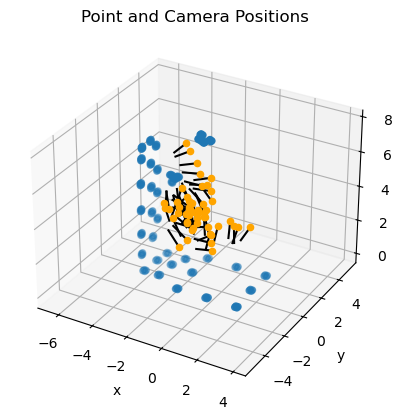

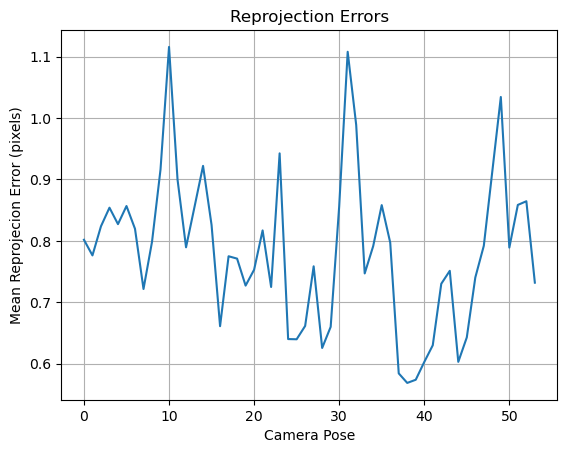

In [3]:
# input_dir = r"C:\Users\qzheng\Documents\GitHub\OpenCSP\example\scene_reconstruction\data\Photomodeler_targets\inputs"
# output_dir = r"C:\Users\qzheng\Documents\GitHub\OpenCSP\example\scene_reconstruction\data\Photomodeler_targets\outputs"
input_dir = r"C:\Users\qzheng\Documents\GitHub\OpenCSP\opencsp\app\scene_reconstruction\test\data\data_measurement_hi_res"
output_dir = r"C:\Users\qzheng\Documents\GitHub\OpenCSP\opencsp\app\scene_reconstruction\test\data\data_measurement_hi_res_outputs"
# example_driver(dir_output_fixture=output_dir, dir_input_fixture=input_dir)
example_driver(output_dir, input_dir)